## Exploratory Data Analysis voor klachten
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten)
2. [Data Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
3. [Train-Test-Split](#train-test-split)
4. ...

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Gebruiker\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Gebruiker\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Gebruiker\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Gebruiker\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Data Analyse

In [4]:
klacht = pd.read_csv("klachten.csv")

In [5]:
klacht.head()

,ID,Datum_ontvangst,Product,Omschrijving,Antwoord_bedrijf
0,2234392,2024-12-03,Bankrekening,ON XX/XX/2016 I had a deposit of XXXX into my ...,Closed with monetary relief
1,2447005,2025-04-21,Bankrekening,Chase Bank accepted a {$3500.00} check for dep...,Closed with explanation
2,2124501,2024-09-21,Bankrekening,I tried to open an account with Bank of Americ...,Closed with explanation
3,1851449,2024-03-27,Bankrekening,On XXXX my account was gotten into on USAA by ...,Closed with explanation
4,2419713,2025-04-04,Bankrekening,I have been deprived of my income as Bank of A...,Closed with explanation


In [6]:
klacht.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14887 entries, 0 to 14886
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                14887 non-null  int64 
 1   Datum_ontvangst   14887 non-null  object
 2   Product           14887 non-null  object
 3   Omschrijving      14887 non-null  object
 4   Antwoord_bedrijf  14887 non-null  object
dtypes: int64(1), object(4)
memory usage: 581.6+ KB


In [7]:
klacht.describe()

,ID
count,1.488700e+04
mean,1.902949e+06
std,3.417599e+05
min,1.290157e+06
25%,1.602146e+06
50%,1.923756e+06
75%,2.205762e+06
max,2.543247e+06


In [8]:
klacht.describe(include=["object"])

,Datum_ontvangst,Product,Omschrijving,Antwoord_bedrijf
count,14887,14887,14887,14887
unique,771,6,14816,5
top,2024-09-21,Incasso,I am filing this complaint because Experian ha...,Closed with explanation
freq,43,4094,10,11610


In [9]:
klacht.isnull().sum()

ID                  0
Datum_ontvangst     0
Product             0
Omschrijving        0
Antwoord_bedrijf    0
dtype: int64

In [10]:
klacht.duplicated().sum()

np.int64(0)

In [11]:
klacht['Product'].unique()

array(['Bankrekening', 'Consumentenkrediet', 'Creditcard', 'Hypotheek',
       'Incasso', 'Kredietregistratie'], dtype=object)

In [12]:
klacht['Antwoord_bedrijf'].unique()

array(['Closed with monetary relief', 'Closed with explanation',
       'Closed with non-monetary relief', 'Closed', 'Untimely response'],
      dtype=object)

In [13]:
klacht['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

#### Visualisaties

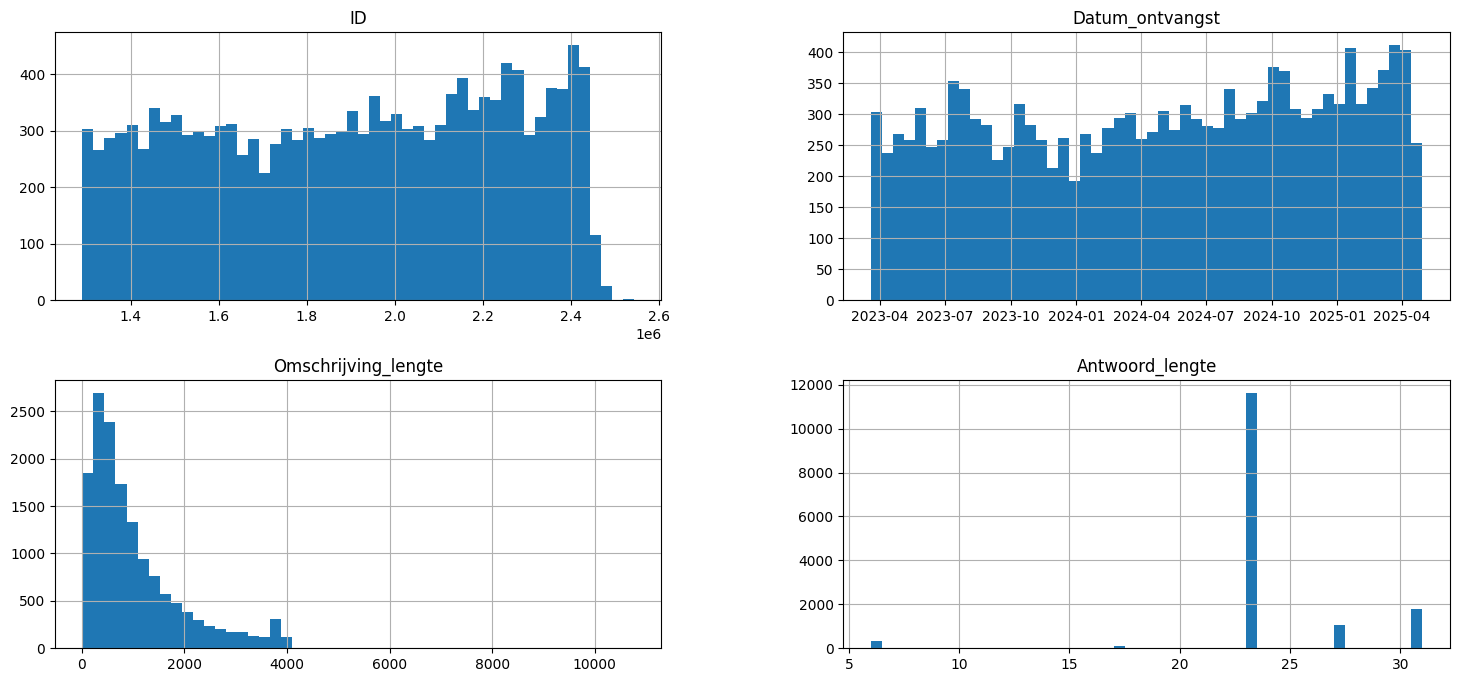

In [21]:
klacht.hist(bins=50, figsize=(18, 8))
plt.show()

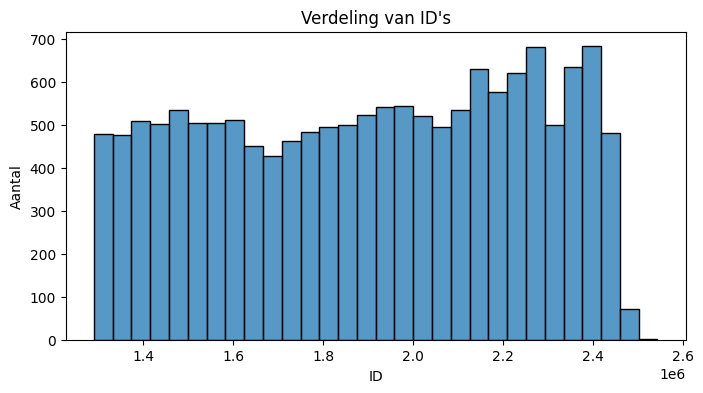

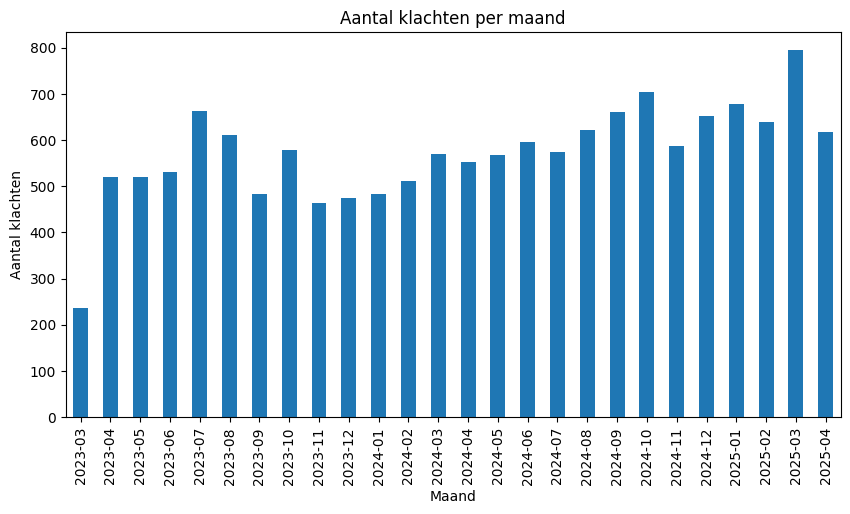

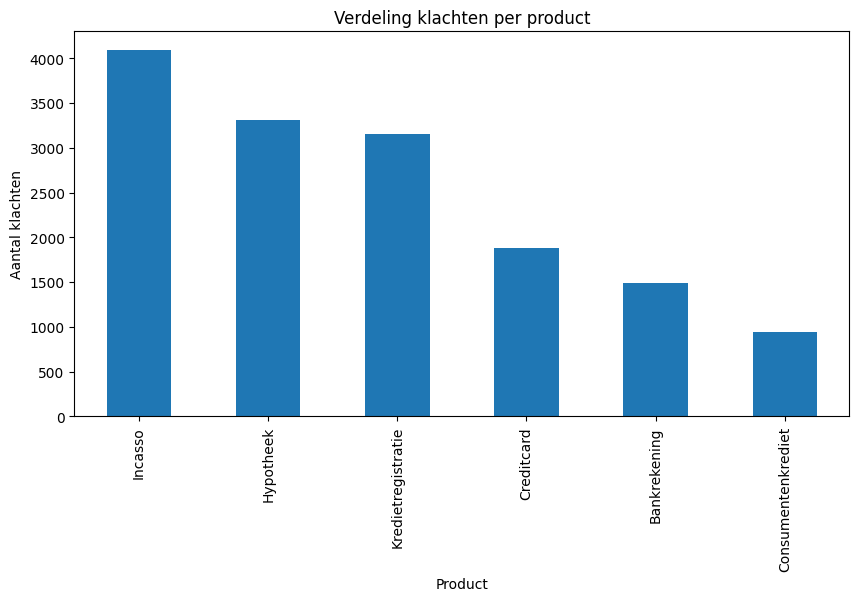

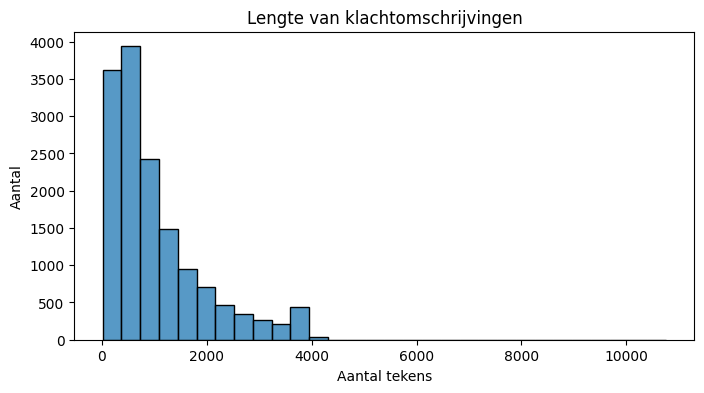

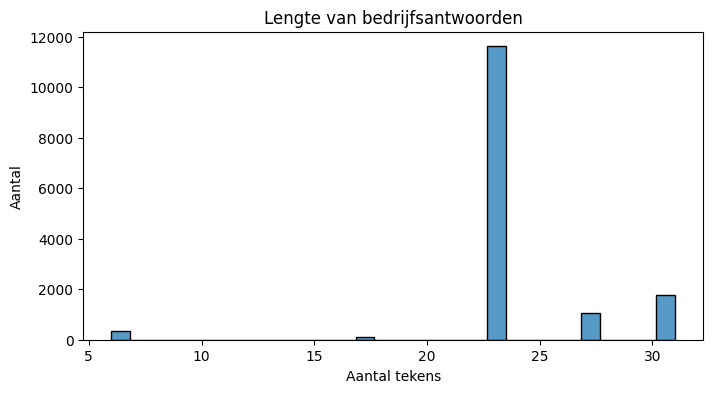

In [15]:
klacht['Datum_ontvangst'] = pd.to_datetime(klacht['Datum_ontvangst'], errors='coerce')

# 1. Histogram voor ID (controle op verdeling, meestal gewoon oplopend)
plt.figure(figsize=(8,4))
sns.histplot(klacht['ID'], bins=30, kde=False)
plt.title("Verdeling van ID's")
plt.xlabel("ID")
plt.ylabel("Aantal")
plt.show()

# 2. Histogram voor Datum_ontvangst (tijdreeks, per maand)
plt.figure(figsize=(10,5))
klacht['Datum_ontvangst'].dt.to_period("M").value_counts().sort_index().plot(kind="bar")
plt.title("Aantal klachten per maand")
plt.xlabel("Maand")
plt.ylabel("Aantal klachten")
plt.show()

# 3. Bar chart voor Product
plt.figure(figsize=(10,5))
klacht['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

# 4. Lengte van Omschrijving (hoeveel tekst per klacht)
klacht['Omschrijving_lengte'] = klacht['Omschrijving'].str.len()
plt.figure(figsize=(8,4))
sns.histplot(klacht['Omschrijving_lengte'], bins=30, kde=False)
plt.title("Lengte van klachtomschrijvingen")
plt.xlabel("Aantal tekens")
plt.ylabel("Aantal")
plt.show()

# 5. Lengte van Antwoord_bedrijf (hoe uitgebreid reageren bedrijven)
klacht['Antwoord_lengte'] = klacht['Antwoord_bedrijf'].str.len()
plt.figure(figsize=(8,4))
sns.histplot(klacht['Antwoord_lengte'], bins=30, kde=False)
plt.title("Lengte van bedrijfsantwoorden")
plt.xlabel("Aantal tekens")
plt.ylabel("Aantal")
plt.show()

### Train-Test Split

In [16]:
# train-test split 80/20
train_set, test_set = train_test_split(klacht, test_size=0.2, random_state=42)

train_set.to_csv('klacht_train.csv', index=False)
test_set.to_csv('klacht_test.csv', index=False)

In [17]:
df_train = pd.read_csv("klacht_train.csv")
df_test = pd.read_csv("klacht_test.csv")

In [19]:
df_train.shape
print("De train dataset bevat {} rijen en {} kolommen.".format(df_train.shape[0], df_train.shape[1]))

df_test.shape
print("De test dataset bevat {} rijen en {} kolommen.".format(df_test.shape[0], df_test.shape[1]))

De train dataset bevat 11909 rijen en 7 kolommen.
De test dataset bevat 2978 rijen en 7 kolommen.
